# Prise en main de `portopt`

Ce notebook fait le tour de la librairie en une vingtaine de minutes : charger des données, construire un portefeuille, lancer un backtest walk-forward, comparer des règles d'allocation, lire les résultats et écrire sa propre règle.

**Prérequis** : `pip install -e ".[dev]"` depuis la racine du dépôt.

**Pour aller plus loin** : `docs/user_guide.pdf` (utilisation détaillée) et `docs/methodology.pdf` (théorie et démonstrations).

| Étape | Module | Ce qu'on fait |
|---|---|---|
| 1 | `data` | obtenir des rendements |
| 2 | `estimator` | transformer une fenêtre de rendements en poids |
| 3 | `backtester` | rejouer la règle dans le temps, sans information future |
| 4 | `metric`, `plot` | mesurer et visualiser |

In [38]:
#%pip install -e "..[dev]"

In [39]:
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from portopt import (load_returns, EqualWeight, InverseVolatility, ERC, HRP, RiskParity,
                     BaseEstimator, Backtester, run_backtests, summary, risk_contributions)
from portopt import metric as M, plot
from portopt.data import simulate_returns

%matplotlib inline
plot.use_style()                                   # fond blanc, couleurs fixes par stratégie
pd.set_option("display.precision", 3)
logging.getLogger("yfinance").setLevel(logging.CRITICAL)

## 1. Les données

On travaille sur 10 ETF multi-actifs : actions (US, développés, émergents, small caps), obligations d'État et crédit, or, matières premières, immobilier.

`load_returns` télécharge les prix ajustés des dividendes, les nettoie et renvoie des **rendements simples quotidiens** : un `DataFrame` avec une ligne par date et une colonne par actif. Sans accès réseau, le notebook bascule sur `simulate_returns()`, un univers simulé réaliste qui porte les mêmes tickers.

In [40]:
#TICKERS = ["SPY", "EFA", "EEM", "IWM", "TLT", "IEF", "LQD", "GLD", "DBC", "VNQ","MTUM", "QUAL", "VLUE", "SIZE", "USMV"]
TICKERS = ["MTUM", "QUAL", "VLUE", "SIZE", "USMV"]
try:
    R = load_returns(TICKERS, start="2014-01-01", cache_dir="data_cache")
    source = "Yahoo Finance"
except Exception as err:
    R = simulate_returns()
    source = f"univers simulé (Yahoo indisponible : {type(err).__name__})"

print(f"Source : {source}")
print(f"{R.shape[0]} dates x {R.shape[1]} actifs, du {R.index[0].date()} au {R.index[-1].date()}")
R.tail(3).style.format("{:+.2%}")

Source : Yahoo Finance
3202 dates x 5 actifs, du 2014-01-03 au 2026-09-28


,MTUM,QUAL,VLUE,SIZE,USMV
date,,,,,
2026-09-24 00:00:00,+0.16%,+0.18%,-0.32%,+0.37%,-0.41%
2026-09-25 00:00:00,+0.33%,+0.47%,+0.59%,+0.30%,+0.10%
2026-09-28 00:00:00,-0.96%,-0.17%,-1.18%,-0.39%,-0.38%


Un premier coup d'œil : rendement et volatilité annualisés de chaque actif, puis les corrélations. On retrouve deux familles, les actifs risqués très corrélés entre eux, et les obligations d'État, peu ou négativement corrélées aux actions.

In [41]:
stats = pd.DataFrame({
    "Rendement ann.": M.annualized_mean(R),
    "Volatilité ann.": M.annualized_volatility(R),
    "Sharpe": M.sharpe_ratio(R),
})
stats.style.format("{:.2f}").format("{:.1%}", subset=["Rendement ann.", "Volatilité ann."])

,Rendement ann.,Volatilité ann.,Sharpe
MTUM,16.4%,20.5%,0.80
QUAL,13.8%,17.2%,0.80
VLUE,13.8%,19.0%,0.73
SIZE,12.0%,17.6%,0.68
USMV,10.9%,13.8%,0.79


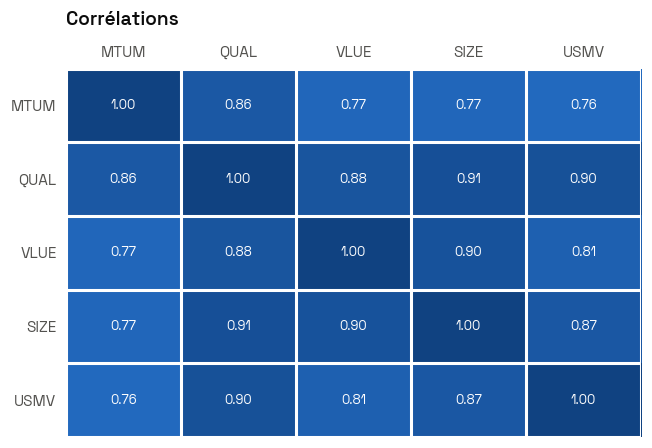

In [42]:
plot.plot_correlation(R, title="Corrélations")
plt.show()

## 2. Construire un portefeuille

Une **règle d'allocation** prend une fenêtre de rendements et renvoie des poids positifs de somme 1. Toutes les règles ont la même interface : `.fit(fenetre)`, puis on lit `.weights_`.

On compare deux règles sur la dernière année :
- **1/N** : le même capital sur chaque actif ;
- **ERC** (*Equal Risk Contribution*) : la même part de **risque** sur chaque actif.

La contribution au risque de l'actif $i$ est $\dfrac{w_i(\Sigma w)_i}{w^\top\Sigma w}$ : la part de la variance du portefeuille qui lui revient. Les contributions somment à 1.

In [43]:
window = R.iloc[-252:]                               # la dernière année
ew = EqualWeight().fit(window)
erc = ERC().fit(window)
cov = erc.cov_

allocation = pd.DataFrame({
    "1/N : capital": ew.weights_,
    "1/N : risque": risk_contributions(ew.weights_, cov),
    "ERC : capital": erc.weights_,
    "ERC : risque": risk_contributions(erc.weights_, cov),
})
allocation.style.format("{:.1%}").background_gradient(cmap="Blues", vmin=0, vmax=0.3)

,1/N : capital,1/N : risque,ERC : capital,ERC : risque
MTUM,20.0%,33.9%,11.1%,20.0%
QUAL,20.0%,16.0%,19.6%,20.0%
VLUE,20.0%,27.9%,12.6%,20.0%
SIZE,20.0%,15.8%,19.0%,20.0%
USMV,20.0%,6.4%,37.7%,20.0%


C'est l'idée centrale de la librairie. **1/N répartit le capital, pas le risque** : les actifs volatils et corrélés entre eux (les actions) concentrent l'essentiel du risque. ERC surpondère les actifs peu volatils (obligations) pour que chaque ligne pèse autant dans le risque total.

Les autres règles disponibles fonctionnent de la même façon :

In [44]:
rules = {
    "1/N": EqualWeight(),
    "InvVol": InverseVolatility(),                          # w_i proportionnel à 1/sigma_i
    "ERC": ERC(),
    "ERC Ledoit-Wolf": ERC(cov_method="ledoit_wolf"),       # covariance débruitée
    "HRP": HRP(),                                           # Hierarchical Risk Parity
}
pd.DataFrame({name: est.fit(window).weights_ for name, est in rules.items()}).style.format("{:.1%}")

,1/N,InvVol,ERC,ERC Ledoit-Wolf,HRP
MTUM,20.0%,10.5%,11.1%,11.2%,2.6%
QUAL,20.0%,22.6%,19.6%,19.7%,24.5%
VLUE,20.0%,13.4%,12.6%,12.7%,4.2%
SIZE,20.0%,21.5%,19.0%,19.2%,19.6%
USMV,20.0%,32.0%,37.7%,37.2%,49.2%


## 3. Le backtest walk-forward

Un portefeuille calculé sur tout l'historique utiliserait de l'information future. Le `Backtester` rejoue la règle dans le temps :

1. à chaque date de rebalancement $t$, la règle est estimée sur les `in_sample` dates précédentes ;
2. le portefeuille est détenu pendant `out_of_sample` dates, ses poids dérivant avec les prix ;
3. on avance de `out_of_sample` dates et on recommence.

Les coûts de transaction sont appliqués au turnover, c'est-à-dire à la somme des achats et ventes nécessaires pour revenir à la cible.

In [45]:
bt = Backtester(R, ERC(), in_sample=252, out_of_sample=21, transaction_cost_bps=5)
r_erc = bt.run()                                     # rendements quotidiens hors échantillon, nets

print(f"{len(r_erc)} jours hors échantillon, {len(bt.weights_)} rebalancements")
print(f"Turnover annuel : {bt.annualized_turnover():.0%}")
print(f"Sharpe : {M.sharpe_ratio(r_erc):.2f}   Drawdown max : {M.max_drawdown(r_erc):.1%}")

2950 jours hors échantillon, 141 rebalancements
Turnover annuel : 25%
Sharpe : 0.79   Drawdown max : -35.5%


Le backtester garde tout ce qu'il a fait : les poids cibles à chaque rebalancement, le turnover, les rendements bruts et nets.

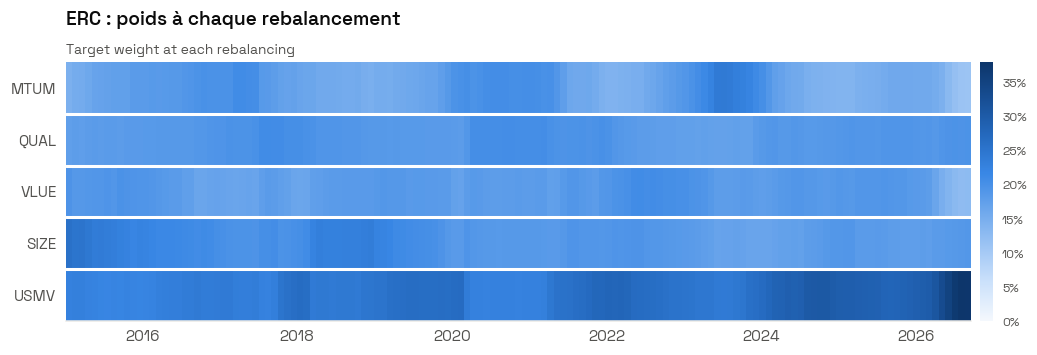

In [46]:
plot.plot_weights_through_time(bt.weights_, "ERC : poids à chaque rebalancement")
plt.show()

## 4. Comparer plusieurs règles

`run_backtests` applique la même grille à chaque règle. Passez un dictionnaire `{libellé: règle}` : les libellés deviennent les colonnes du résultat.

In [47]:
rets, bts = run_backtests(R, rules, in_sample=252, out_of_sample=21, transaction_cost_bps=5)
turnover = {name: b.annualized_turnover() for name, b in bts.items()}
table = summary(rets, turnover=turnover)

rows = ["CAGR", "Ann. vol", "Sharpe", "Max DD", "CVaR 95%", "Ann. turnover"]
pct = ["CAGR", "Ann. vol", "Max DD", "CVaR 95%", "Ann. turnover"]
(table.loc[rows].T.style
    .format("{:.1%}", subset=pct).format("{:.2f}", subset=["Sharpe"])
    .highlight_max(subset=["Sharpe"], color="#cde2fb"))

,CAGR,Ann. vol,Sharpe,Max DD,CVaR 95%,Ann. turnover
1/N,12.6%,16.9%,0.79,-35.8%,2.5%,16.1%
InvVol,12.3%,16.5%,0.79,-35.5%,2.5%,24.1%
ERC,12.3%,16.5%,0.79,-35.5%,2.5%,24.7%
ERC Ledoit-Wolf,12.3%,16.5%,0.79,-35.5%,2.5%,24.6%
HRP,11.3%,16.1%,0.75,-35.8%,2.4%,102.3%


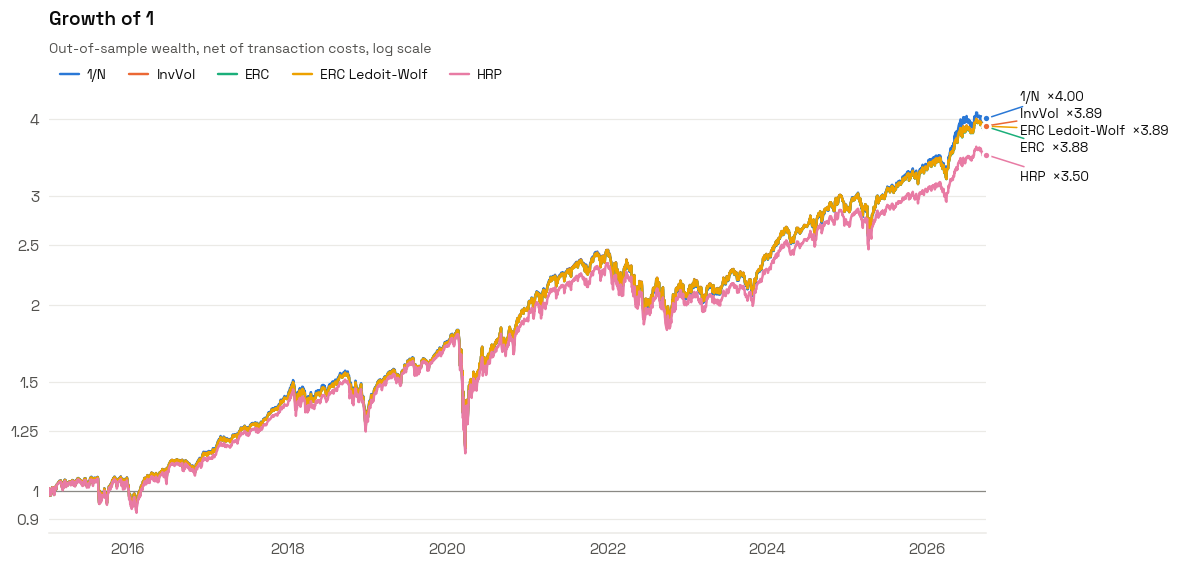

In [48]:
plot.plot_wealth(rets)
plt.show()

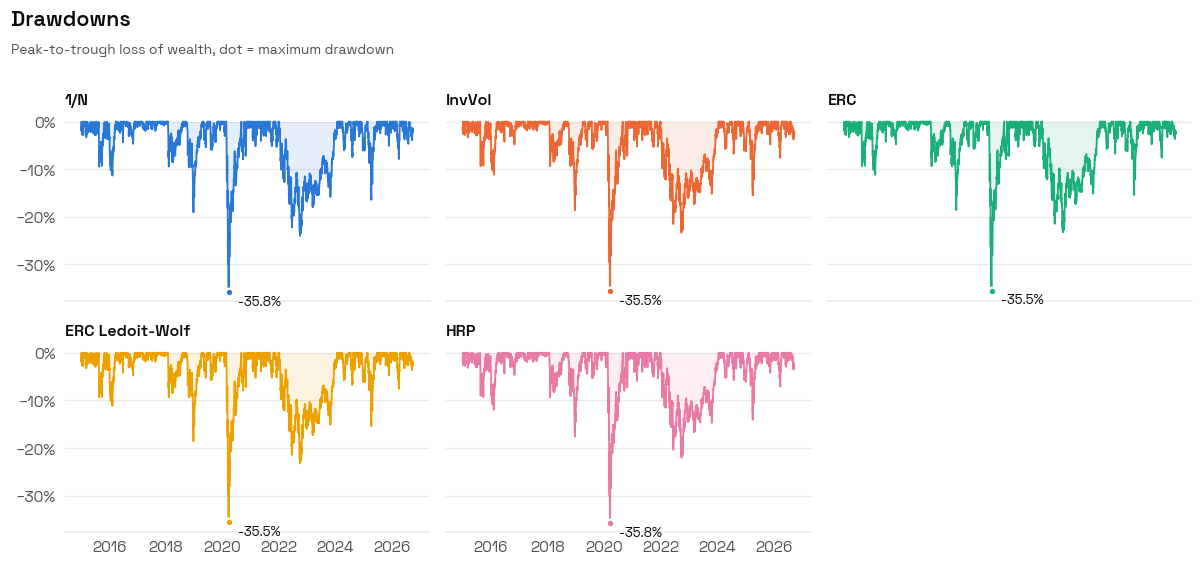

In [49]:
plot.plot_drawdowns(rets)
plt.show()

Où est le risque de chaque stratégie ? La contribution moyenne de chaque actif au risque, sur tous les rebalancements :

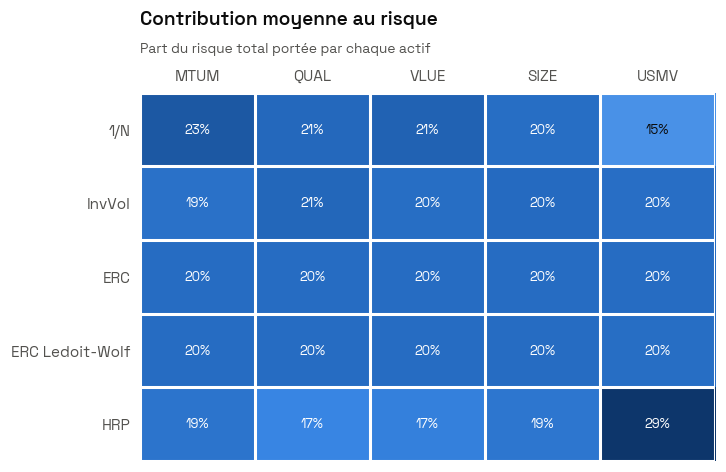

In [50]:
avg_rc = pd.DataFrame({name: b.risk_contributions().iloc[1:].mean() for name, b in bts.items()}).T
plot.plot_heatmap(avg_rc, "Contribution moyenne au risque", "Part du risque total portée par chaque actif")
plt.show()

## 5. Les écarts sont-ils significatifs ?

Un backtest n'est qu'une trajectoire. Pour des rendements indépendants, l'erreur standard d'un Sharpe annualisé estimé sur $Y$ années vaut environ

$$\mathrm{se}(\widehat{\mathrm{SR}}) \approx \frac{1}{\sqrt{Y}}$$

Si deux Sharpe diffèrent de moins d'une erreur standard, le backtest ne permet pas de les départager. Le *Probabilistic Sharpe Ratio* (PSR) donne la probabilité que le vrai Sharpe dépasse un seuil, en tenant compte de l'asymétrie et des queues épaisses.

In [51]:
years = len(rets) / 252
se = 1 / np.sqrt(years)
sig = pd.DataFrame({
    "Sharpe": M.sharpe_ratio(rets),
    "Écart à 1/N (en erreurs std.)": (M.sharpe_ratio(rets) - M.sharpe_ratio(rets["1/N"])) / se,
    "P(SR > 0)": M.probabilistic_sharpe_ratio(rets),
    "P(SR > 0.5)": M.probabilistic_sharpe_ratio(rets, sr_benchmark=0.5),
})
print(f"{years:.1f} années hors échantillon, erreur standard du Sharpe : {se:.2f}")
sig.style.format("{:.2f}")

11.7 années hors échantillon, erreur standard du Sharpe : 0.29


,Sharpe,Écart à 1/N (en erreurs std.),P(SR > 0),P(SR > 0.5)
1/N,0.79,0.00,1.00,0.83
InvVol,0.79,-0.00,1.00,0.83
ERC,0.79,-0.00,1.00,0.83
ERC Ledoit-Wolf,0.79,-0.00,1.00,0.83
HRP,0.75,-0.13,0.99,0.80


## 6. Écrire sa propre règle

Il suffit d'hériter de `BaseEstimator` et d'écrire `_compute_weights`, qui reçoit une fenêtre sans valeur manquante et renvoie un vecteur de poids. La normalisation, la gestion des actifs non cotés et tout le backtest sont pris en charge par la librairie.

Exemple : le portefeuille de **variance minimale** long-only, $\min_w w^\top\Sigma w$ sous $w \ge 0$ et $\sum_i w_i = 1$.

> **Attention** : les variances quotidiennes sont de l'ordre de $10^{-5}$. Sans mise à l'échelle, SLSQP s'arrête dès le premier pas et renvoie 1/N sans erreur. On normalise donc la covariance, ce qui ne change pas la solution, et on fournit le gradient.

In [52]:
from scipy.optimize import minimize

class MinVariance(BaseEstimator):
    def _compute_weights(self, returns):
        cov = self._cov(returns)                     # respecte cov_method
        cov = cov / np.trace(cov)                    # mise à l'échelle
        n = cov.shape[0]
        res = minimize(lambda w: w @ cov @ w, np.full(n, 1 / n), jac=lambda w: 2 * cov @ w,
                       method="SLSQP", bounds=[(0, 1)] * n,
                       constraints={"type": "eq", "fun": lambda w: w.sum() - 1},
                       options={"ftol": 1e-12, "maxiter": 500})
        return res.x

MinVariance(cov_method="ledoit_wolf").fit(window).weights_.to_frame("Min variance").T.style.format("{:.1%}")

,MTUM,QUAL,VLUE,SIZE,USMV
Min variance,6.6%,2.6%,0.0%,0.0%,90.8%


La nouvelle règle s'utilise exactement comme les autres. La théorie prévoit $\sigma_{\text{MV}} \le \sigma_{\text{ERC}} \le \sigma_{1/N}$ : on le vérifie hors échantillon.

In [53]:
rets_mv, _ = run_backtests(R, {"Min variance": MinVariance(cov_method="ledoit_wolf")}, 252, 21,
                           transaction_cost_bps=5)
comparison = summary(pd.concat([rets[["1/N", "ERC"]], rets_mv], axis=1))
comparison.loc[["Ann. vol", "Sharpe", "Max DD"]].style.format("{:.2f}")

,1/N,ERC,Min variance
Ann. vol,0.17,0.17,0.14
Sharpe,0.79,0.79,0.73
Max DD,-0.36,-0.36,-0.33


## 7. Robustesse aux paramètres

La longueur de la fenêtre et la fréquence de rebalancement sont des choix arbitraires. Un résultat fiable doit y résister : on regarde le **classement** des règles sur une grille, pas le meilleur couple de paramètres (ce serait sur-ajuster le backtest).

In [54]:
compared = {"1/N": EqualWeight(), "ERC": ERC(), "HRP": HRP()}
ranks = {}
for L in (126, 252, 504):
    for H in (5, 21, 63):
        out, _ = run_backtests(R, compared, in_sample=L, out_of_sample=H, transaction_cost_bps=5)
        ranks[(L, H)] = M.sharpe_ratio(out).rank(ascending=False).astype(int)

grid = pd.DataFrame(ranks).T
grid.index.names = ["fenêtre", "détention"]
grid.style.background_gradient(cmap="Blues_r", vmin=1, vmax=3)

## 8. Rapport complet et suite

`save_report` écrit tous les graphiques de comparaison en PNG ; les résultats s'exportent en CSV.

In [55]:
paths = plot.save_report(rets, bts, "outputs/charts")
table.to_csv("outputs/summary.csv")
rets.to_csv("outputs/oos_returns.csv")
print(f"{len(paths)} graphiques dans outputs/charts/")

12 graphiques dans outputs/charts/


### Pour aller plus loin

- **Budgets de risque** : `RiskParity(budgets={...})` fixe la part de risque de chaque actif (par exemple doubler celle des obligations).
- **Covariance** : `cov_method="ledoit_wolf"`, `"ewma"` ou n'importe quelle fonction `returns -> ndarray`.
- **HRP** : `HRP(linkage="ward", split="dendrogram")` suit l'arbre de clustering au lieu de couper la liste en deux.
- **Autres fréquences** : `resample_returns(R, "W-FRI")` puis `periods_per_year=52` dans les fonctions de `metric`.
- **Documentation** : `docs/user_guide.pdf` pour chaque paramètre et les erreurs fréquentes, `docs/methodology.pdf` pour les définitions et démonstrations.